# 08 Cross Encoder Fraud Verification

**Project:** Insurance Fraud Detection Assistant

**Notebook:** `08-cross-encoder-fraud-verification.ipynb`

In [1]:
# ==========================================
# Notebook 08
# Cross Encoder Fraud Verification
# ==========================================

import pandas as pd
import numpy as np

from sentence_transformers import CrossEncoder

import matplotlib.pyplot as plt
import seaborn as sns

d:\Books\projects-nlp-transformers-learning\.projectnlps\Lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


In [2]:
claims_df = pd.read_csv("../data/insurance_claims.csv")

In [3]:
claims_df.head()

,claim_id,claimant_name,vehicle_vin,mechanic_shop,clinic_name,lawyer,claimant_statement,police_report,adjuster_notes,medical_bill,fraud_label
0,CLM001,Wendy Holland,FqH15433919443,Rapid Auto Repair,Care First Clinic,Smith & Associates,A vehicle rear-ended me while I was waiting at...,Witnesses confirmed another driver caused the ...,Section international though many movement.,5072,0
1,CLM002,Douglas Lara,acF49501195178,Rapid Auto Repair,Wellness Recovery Center,Anderson Legal,The vehicle changed lanes unexpectedly and hit...,Police observed damage consistent with reporte...,Budget Mrs part spend middle threat smile incr...,1541,0
2,CLM003,Chloe Murphy,xeQ24677572737,Rapid Auto Repair,Care First Clinic,Justice Partners,I was stopped at a red light when another vehi...,Accident report indicates claimant followed tr...,Similar never box line.,20226,1
3,CLM004,Jodi Reynolds MD,sPL40843321198,Rapid Auto Repair,Wellness Recovery Center,Justice Partners,The vehicle changed lanes unexpectedly and hit...,Police observed damage consistent with reporte...,Section season nor political bank.,7723,0
4,CLM005,Elizabeth Patel,mmr35740163797,Prime Vehicle Repair,Wellness Recovery Center,Smith & Associates,I was driving through an intersection when ano...,Witnesses confirmed another driver caused the ...,Kind compare across audience society.,23376,0


In [4]:
cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

In [5]:
claim_text = """

I was stopped at a red light when another vehicle hit me.
"""

In [6]:
police_text = """

Police report indicates claimant was travelling at 55 mph.
"""

In [7]:
score = cross_encoder.predict([(claim_text, police_text)])[0]

In [8]:
score

-8.94854

In [13]:
def verify_claim(claimant_statement, police_report, model):

    score = model.predict([(str(claimant_statement), str(police_report))])[0]

    return float(score)

In [14]:
verify_claim(claim_text, police_text, cross_encoder)

-8.948539733886719

In [15]:
verification_results = []

In [ ]:
for _, row in claims_df.iterrows():
    score = verify_claim(row["claimant_statement"], row["police_report"], cross_encoder)
    verification_results.append(
        {
            "claim_id": row["claim_id"],
            "verification_score": score,
            "fraud_label": row["fraud_label"],
        }
    )

In [21]:
verification_df = pd.DataFrame(verification_results)

In [22]:
verification_df.head()

,claim_id,verification_score,fraud_label
0,CLM015,-0.831068,0
1,CLM001,-7.864964,0
2,CLM002,-6.410931,0
3,CLM003,-8.468349,1
4,CLM004,-6.410931,0


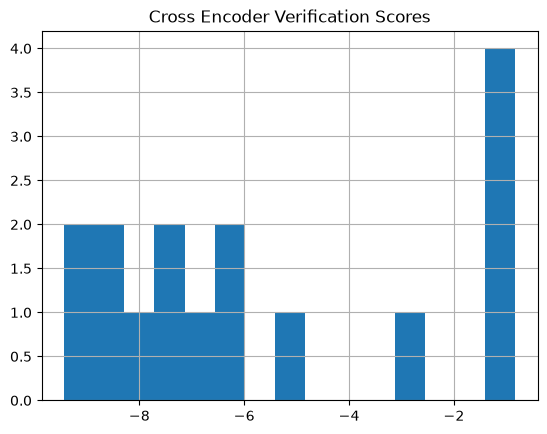

In [23]:
verification_df["verification_score"].hist(bins=15)

plt.title("Cross Encoder Verification Scores")

plt.show()

In [24]:
verification_df.groupby("fraud_label")["verification_score"].mean()

fraud_label
0   -5.263258
1   -6.214492
Name: verification_score, dtype: float64

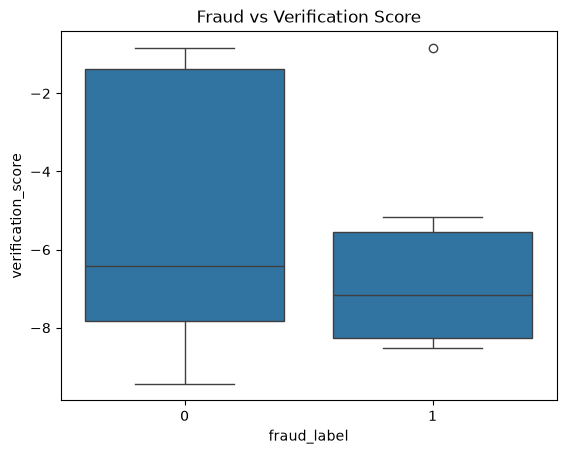

In [25]:
sns.boxplot(data=verification_df, x="fraud_label", y="verification_score")

plt.title("Fraud vs Verification Score")

plt.show()

In [26]:
min_score = verification_df["verification_score"].min()

max_score = verification_df["verification_score"].max()

In [27]:
verification_df["normalized_score"] = (
    verification_df["verification_score"] - min_score
) / (max_score - min_score)

In [28]:
verification_df.head()

,claim_id,verification_score,fraud_label,normalized_score
0,CLM015,-0.831068,0,1.000000
1,CLM001,-7.864964,0,0.182147
2,CLM002,-6.410931,0,0.351212
3,CLM003,-8.468349,1,0.111990
4,CLM004,-6.410931,0,0.351212


In [29]:
THRESHOLD = 0.40

In [30]:
verification_df["fraud_flag"] = verification_df["normalized_score"] < THRESHOLD

In [31]:
verification_df[["claim_id", "normalized_score", "fraud_flag"]]

,claim_id,normalized_score,fraud_flag
0,CLM015,1.000000,False
1,CLM001,0.182147,True
2,CLM002,0.351212,True
3,CLM003,0.111990,True
4,CLM004,0.351212,True
5,CLM005,1.000000,False
6,CLM006,0.496726,False
7,CLM007,0.204733,True
8,CLM008,0.213401,True
9,CLM009,0.105872,True


In [32]:
suspicious_claims = verification_df[verification_df["fraud_flag"]]

In [33]:
suspicious_claims

,claim_id,verification_score,fraud_label,normalized_score,fraud_flag
1,CLM001,-7.864964,0,0.182147,True
2,CLM002,-6.410931,0,0.351212,True
3,CLM003,-8.468349,1,0.111990,True
4,CLM004,-6.410931,0,0.351212,True
7,CLM007,-7.670719,0,0.204733,True
8,CLM008,-7.596171,1,0.213401,True
9,CLM009,-8.520964,1,0.105872,True
11,CLM011,-6.710953,1,0.316328,True
13,CLM013,-9.320751,0,0.012878,True
14,CLM014,-9.431512,0,0.000000,True


In [ ]:
for claim_id in suspicious_claims["claim_id"]:
    claim = claims_df[claims_df["claim_id"] == claim_id].iloc[0]
    print("=" * 80)

    print("Claim ID:", claim_id)

    print()
    print("CLAIMANT:")

    print(claim["claimant_statement"])

    print()
    print("POLICE:")

    print(claim["police_report"])

    print("\n")

Claim ID: CLM001

CLAIMANT:
A vehicle rear-ended me while I was waiting at a traffic signal.

POLICE:
Witnesses confirmed another driver caused the accident.


Claim ID: CLM002

CLAIMANT:
The vehicle changed lanes unexpectedly and hit my car.

POLICE:
Police observed damage consistent with reported collision.


Claim ID: CLM003

CLAIMANT:
I was stopped at a red light when another vehicle hit me.

POLICE:
Accident report indicates claimant followed traffic rules.


Claim ID: CLM004

CLAIMANT:
The vehicle changed lanes unexpectedly and hit my car.

POLICE:
Police observed damage consistent with reported collision.


Claim ID: CLM007

CLAIMANT:
I was driving through an intersection when another vehicle struck my car.

POLICE:
Traffic camera footage supports claimant statement.


Claim ID: CLM008

CLAIMANT:
I was traveling within the speed limit when the accident occurred.

POLICE:
Accident report indicates claimant followed traffic rules.


Claim ID: CLM009

CLAIMANT:
The driver failed to

In [40]:
cosine_df = pd.read_csv("../data/cross_document_similarity_results.csv")

In [41]:
comparison_df = pd.merge(cosine_df, verification_df, on=["claim_id", "fraud_label"])

In [42]:
comparison_df[["claim_id", "similarity", "normalized_score"]].head()

,claim_id,similarity,normalized_score
0,CLM001,0.464861,0.182147
1,CLM002,0.514360,0.351212
2,CLM003,0.492316,0.111990
3,CLM004,0.514360,0.351212
4,CLM005,0.567865,1.000000


In [43]:
comparison_df[["similarity", "normalized_score"]].corr()

,similarity,normalized_score
similarity,1.000000,0.352659
normalized_score,0.352659,1.000000


In [44]:
high_risk_claims = verification_df.sort_values(by="normalized_score", ascending=True)

In [45]:
high_risk_claims.head(10)

,claim_id,verification_score,fraud_label,normalized_score,fraud_flag
14,CLM014,-9.431512,0,0.000000,True
13,CLM013,-9.320751,0,0.012878,True
9,CLM009,-8.520964,1,0.105872,True
3,CLM003,-8.468349,1,0.111990,True
1,CLM001,-7.864964,0,0.182147,True
7,CLM007,-7.670719,0,0.204733,True
8,CLM008,-7.596171,1,0.213401,True
11,CLM011,-6.710953,1,0.316328,True
2,CLM002,-6.410931,0,0.351212,True
4,CLM004,-6.410931,0,0.351212,True


In [46]:
investigation_queue = high_risk_claims[["claim_id", "normalized_score"]]

In [47]:
investigation_queue

,claim_id,normalized_score
14,CLM014,0.000000
13,CLM013,0.012878
9,CLM009,0.105872
3,CLM003,0.111990
1,CLM001,0.182147
7,CLM007,0.204733
8,CLM008,0.213401
11,CLM011,0.316328
2,CLM002,0.351212
4,CLM004,0.351212


In [48]:
verification_df.to_csv("../data/cross_encoder_verification.csv", index=False)

In [49]:
investigation_queue.to_csv("../data/investigation_queue.csv", index=False)